# Validate model

In [1]:
run = "j"

In [2]:
import sys
sys.path.append("../../src/ml")

In [3]:
from load import LoadML
loader = LoadML(run="j")
results = loader.load_training_results("xgb_optimised")
print(results.keys())

from validate import Validate
val = Validate(results, run=run)

[LoadML] [OK] Initialised
[LoadML] [OK] Loaded training results for 'xgb_optimised' from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/results/xgb_optimised
dict_keys(['tag', 'model', 'feature_names', 'y_train', 'y_test', 'y_pred', 'y_proba', 'y_proba_train', 'X_test', 'scaler', 'metadata_test', 'cv_threshold', 'cv_threshold_std', 'cv_money_table', 'cv_metrics'])
[Validate] [OK] Initialised analyser for model: xgb_optimised


In [4]:
help(val)

Help on Validate in module validate object:

class Validate(builtins.object)
 |  Validate(results, run='j', img_out_path=None, verbosity=1)
 |
 |  Validate and analyse trained model. Works with results dict from Train.train().
 |
 |  Methods defined here:
 |
 |  __init__(self, results, run='j', img_out_path=None, verbosity=1)
 |      Initialise with Train.train() results dict.
 |
 |  cv_money_table(self, cv_money, save_csv=True)
 |      Display CV-averaged money table from results['cv_money_table'].
 |
 |  find_threshold(self, min_eff=0.999, n_thresholds=10000, plot=True, out_path=None, show=True)
 |      Find highest threshold meeting min_eff event-level veto efficiency.
 |
 |  get_events_by_threshold(self, threshold, above=False)
 |      Select test events by event-level max score. Returns DataFrame with all coincidences.
 |
 |  money_table(self, X, y, metadata, threshold=None, dT_min=0, dT_max=150, save_csv=True)
 |      Event-level comparison of ML model vs dT window cut.
 |
 |  pl


Feature importance:
  PEs            : 0.4957
  crv_x          : 0.3092
  nLayers        : 0.1476
  dT             : 0.0250
  crv_y          : 0.0120
  crv_z          : 0.0036
  nHits          : 0.0031
  angle          : 0.0029
  sector         : 0.0009
[Validate] [OK] Saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/xgb_optimised/bar_feature_importance.png


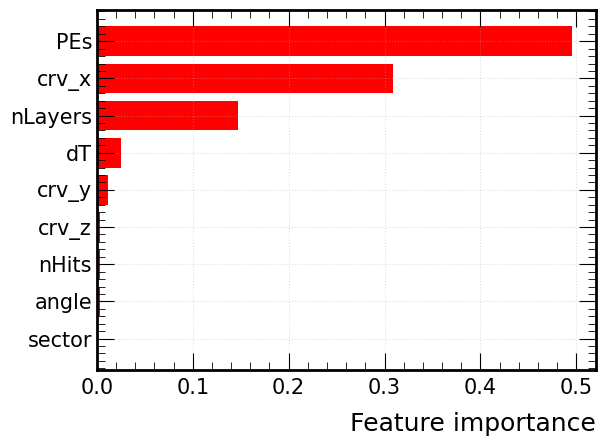

{'crv_x': np.float32(0.30923316),
 'crv_y': np.float32(0.012006102),
 'crv_z': np.float32(0.0035758012),
 'PEs': np.float32(0.49567077),
 'dT': np.float32(0.024956107),
 'nHits': np.float32(0.0030805776),
 'nLayers': np.float32(0.14763051),
 'angle': np.float32(0.0029155705),
 'sector': np.float32(0.00093136955)}

In [5]:
val.plot_feature_importance()

[Validate] [OK] Saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/xgb_optimised/roc_curve.png


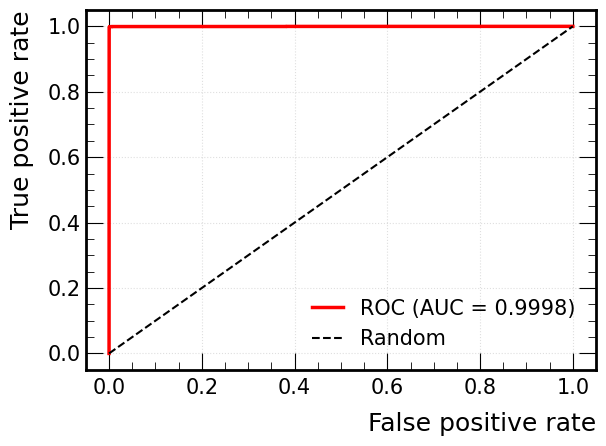

In [6]:
val.plot_roc(show=True)

In [7]:
# should be passed from training results
threshold = results["cv_threshold"]

[Validate] [OK] Saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/xgb_optimised/h1_score_distribution.png


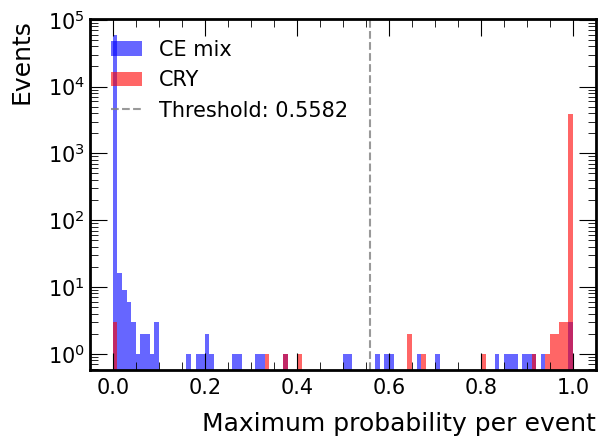

In [8]:
val.plot_score_distribution(threshold=threshold)

[Validate] [INFO] Events below threshold 0.5582:
  CRY:    6
  CE mix: 59451
[Validate] [OK] Saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/xgb_optimised/h1_low_score_physics.png


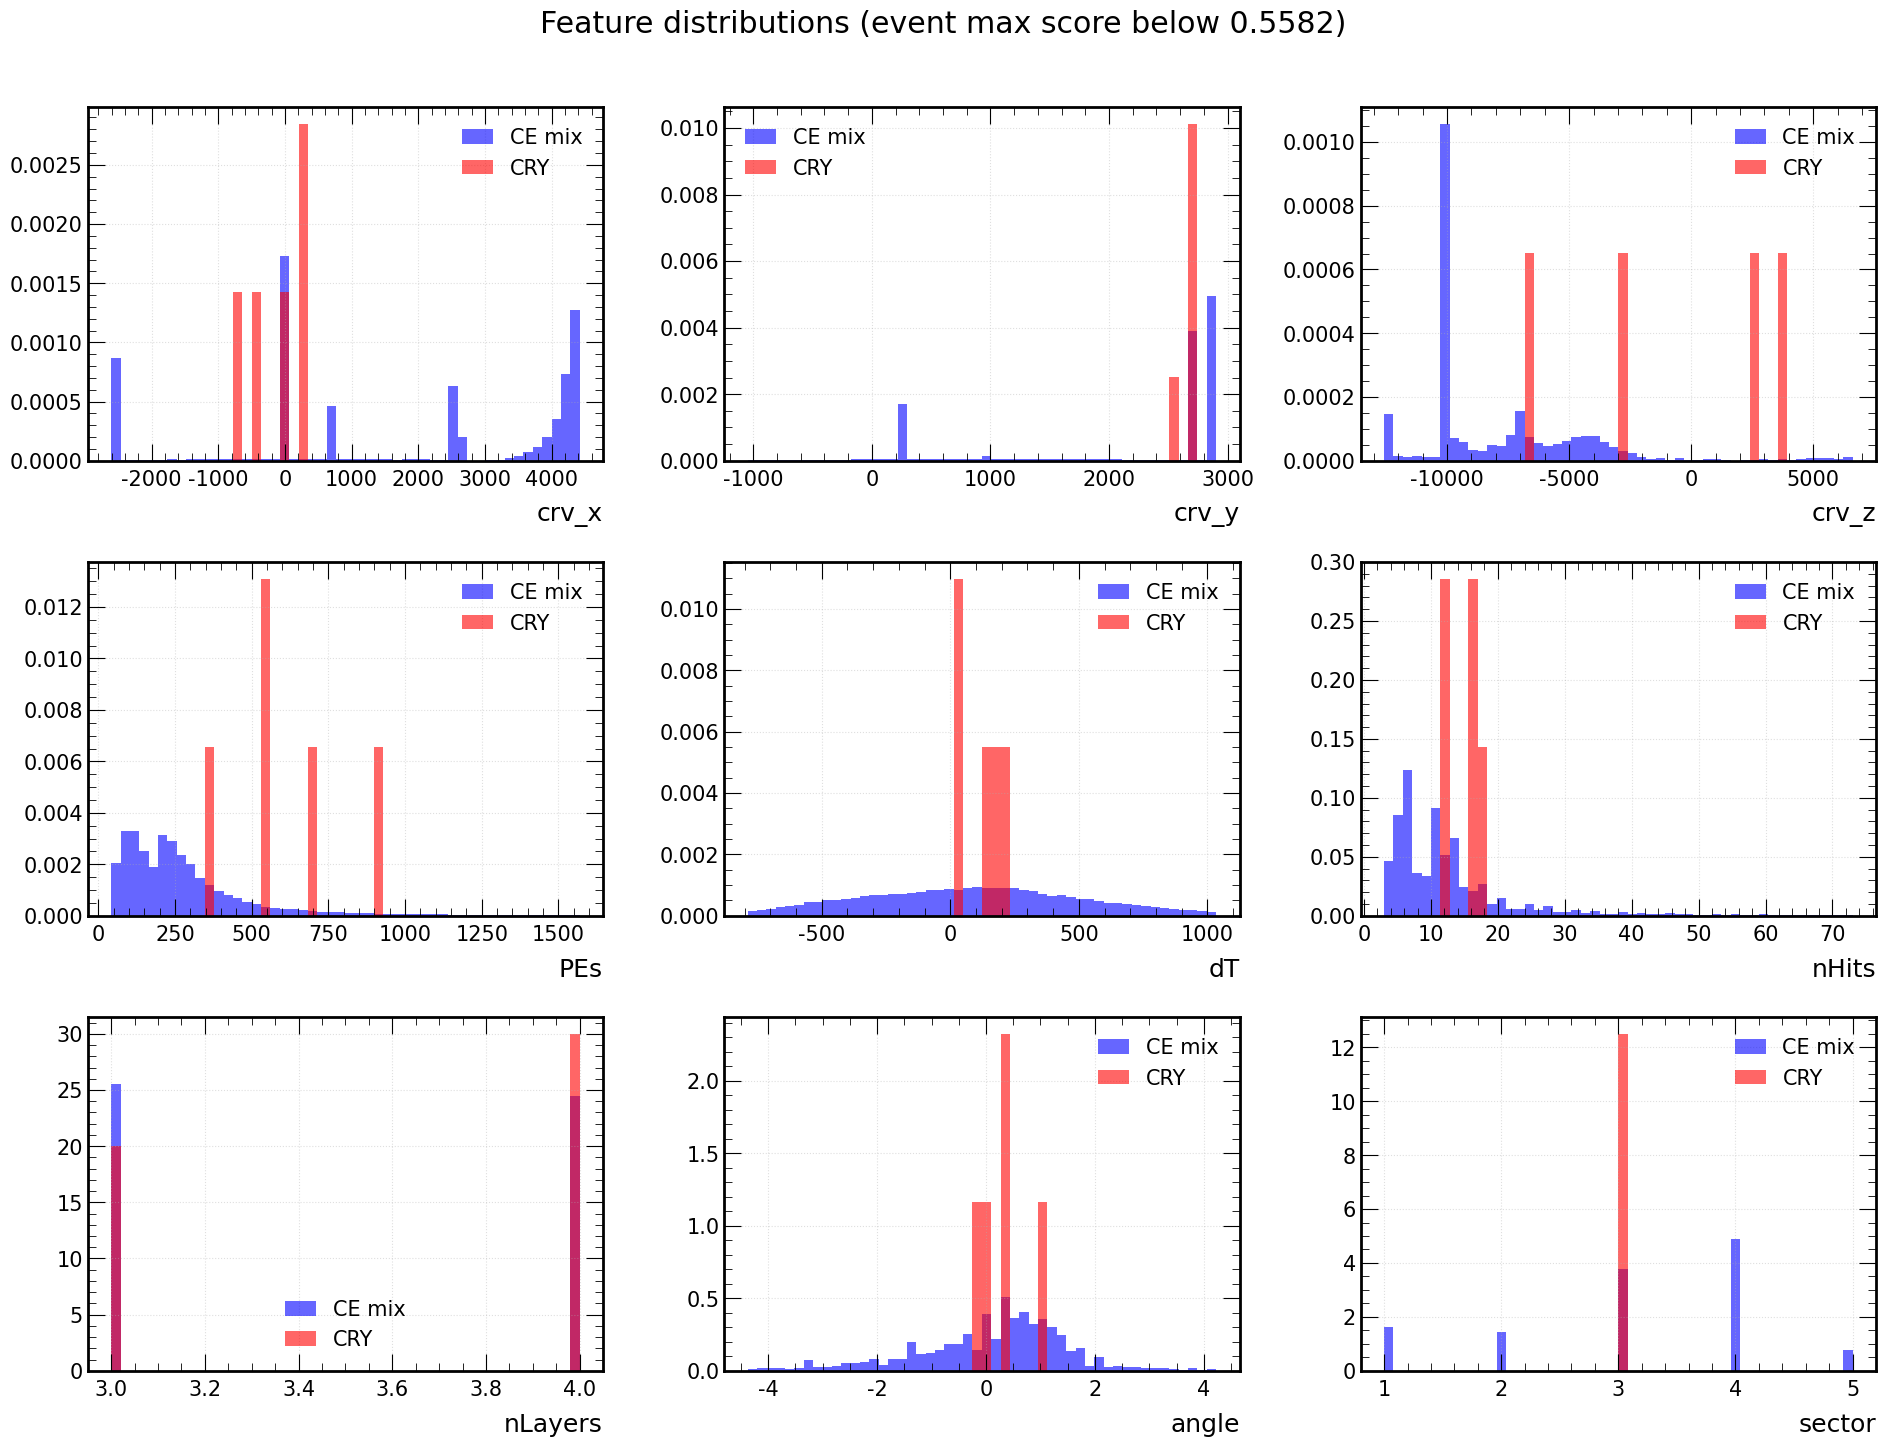

In [9]:
val.plot_physics_by_score(
    threshold=threshold,
    above=False
)

In [10]:
results.keys()

dict_keys(['tag', 'model', 'feature_names', 'y_train', 'y_test', 'y_pred', 'y_proba', 'y_proba_train', 'X_test', 'scaler', 'metadata_test', 'cv_threshold', 'cv_threshold_std', 'cv_money_table', 'cv_metrics'])

In [11]:
df_money_cv = val.cv_money_table(results["cv_money_table"])
display(df_money_cv)

[Validate] [OK] Saved CV money table to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/results/xgb_optimised/cv_money_table.csv


,Metric,ML model,dT cut,Description
0,Veto efficiency,99.923 +/- 0.000%,99.949 +/- 0.028%,Fraction of cosmics vetoed
1,Deadtime,0.023 +/- 0.014%,11.038 +/- 0.101%,Fraction of CE mix vetoed
2,Veto purity,99.659 +/- 0.216%,37.327 +/- 0.309%,"Of vetoed events, fraction that are cosmics"
3,Overall accuracy,99.974 +/- 0.013%,89.640 +/- 0.098%,Overall correct classification rate
4,Figure of merit,99.901 +/- 0.014%,88.916 +/- 0.114%,eff_veto * (1 - deadtime)
